# 🌳 Árbol de Decisión — Regresión de Vida Promedio (Dogs API)

Notebook analítico para entrenar y evaluar un `DecisionTreeRegressor` sobre el dataset de razas de perros.

- **X (predictores)**: `log_peso`, `diferencia_sexual_peso`, `hipoalergenico`
- **y (objetivo)**: `vida_promedio` (años)
- **Modelo**: `DecisionTreeRegressor` (scikit-learn)

La estructura y el flujo imitan `arbol_decision_clima.ipynb`, adaptado a los datos de `dogs_normalized.csv`.


## I. Configuración Inicial — Importaciones y Estilo Visual

Se importan librerías estándar de análisis, métricas de regresión y el modelo de árbol.


In [3]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

# Estilo visual consistente con el proyecto
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('✅ Librerías importadas correctamente')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   seaborn {sns.__version__}')


✅ Librerías importadas correctamente
   pandas  2.3.3
   numpy   2.4.3
   seaborn 0.13.2


## II. Carga de Datos desde CSV (Dogs API)

Leemos el dataset ya normalizado (salida del pipeline/ETL de la API).

Archivo esperado: `../data/dogs_normalized.csv`


In [4]:
# ── CELDA 2: Carga de datos desde CSV ─────────────────────────
df = pd.read_csv('../data/dogs_normalized.csv')

print('✅ Datos cargados desde CSV')
print(f'   Filas    : {df.shape[0]:,}')
print(f'   Columnas : {df.shape[1]}')

print('\n📋 Valores nulos:')
print(df.isnull().sum())

print('\n📋 Primeras filas:')
df.head()


✅ Datos cargados desde CSV
   Filas    : 283
   Columnas : 11

📋 Valores nulos:
raza                      0
vida_min                  0
vida_max                  0
vida_promedio             0
peso_macho_max            0
peso_hembra_max           0
peso_promedio             0
categoria_peso            0
diferencia_sexual_peso    0
hipoalergenico            0
fecha_extraccion          0
dtype: int64

📋 Primeras filas:


,raza,vida_min,vida_max,vida_promedio,peso_macho_max,peso_hembra_max,peso_promedio,categoria_peso,diferencia_sexual_peso,hipoalergenico,fecha_extraccion
0,Affenpinscher,14,16,15.0,5,5,5.0,Muy pequeño,0,True,2026-03-26T12:16:51.082919
1,Afghan Hound,12,14,13.0,27,25,26.0,Mediano,2,False,2026-03-26T12:16:51.082954
2,Airedale Terrier,12,14,13.0,23,20,21.5,Mediano,3,False,2026-03-26T12:16:51.082964
3,Akita,10,12,11.0,60,50,55.0,Gigante,10,False,2026-03-26T12:16:51.082972
4,Alaskan Klee Kai,12,15,13.5,7,7,7.0,Muy pequeño,0,False,2026-03-26T12:16:51.082980


In [5]:
# ── CELDA 3: Preparar variables (features) y vectores X / y ───
# Feature engineering mínimo para el árbol (sin escalado):
# 1) log del peso promedio (captura mejor la no linealidad)
df['log_peso'] = np.log(df['peso_promedio'])

# 2) Convertir hipoalergenico (True/False) a 0/1
hipo = df['hipoalergenico']
if hipo.dtype == bool:
    df['hipoalergenico'] = hipo.astype(int)
else:
    df['hipoalergenico'] = (hipo.astype(str).str.lower() == 'true').astype(int)

features = ['log_peso', 'diferencia_sexual_peso', 'hipoalergenico']
X = df[features].values
y = df['vida_promedio'].values

print('✅ Features y target listos')
print(f'Features: {features}')
print(f'X shape: {X.shape}  (predictores)')
print(f'y shape: {y.shape}  (objetivo: vida_promedio)')

print('\n📊 Estadísticas descriptivas (principales columnas):')
df[['vida_promedio', 'peso_promedio', 'log_peso', 'diferencia_sexual_peso', 'hipoalergenico']].describe().round(2)


✅ Features y target listos
Features: ['log_peso', 'diferencia_sexual_peso', 'hipoalergenico']
X shape: (283, 3)  (predictores)
y shape: (283,)  (objetivo: vida_promedio)

📊 Estadísticas descriptivas (principales columnas):


,vida_promedio,peso_promedio,log_peso,diferencia_sexual_peso,hipoalergenico
count,283.00,283.00,283.00,283.00,283.00
mean,13.01,26.61,3.00,1.05,0.05
std,1.43,19.73,0.80,3.01,0.21
min,7.00,3.00,1.10,0.00,0.00
25%,13.00,11.00,2.40,0.00,0.00
50%,13.00,25.00,3.22,0.00,0.00
75%,13.50,32.00,3.47,0.00,0.00
max,17.50,110.00,4.70,20.00,1.00


## II. Bloque de Lógica — Función de Evaluación por Split

Se encapsula el entrenamiento y la evaluación para comparar tres particiones (80/20, 70/30, 60/40).

Se calculan métricas sobre el conjunto de prueba: **R2, MSE, RMSE, MAE** y se generan dos gráficos por split.


In [6]:
# ── CELDA 4: Función de evaluación reutilizable ──────────────
import os as _os
from statsmodels.nonparametric.smoothers_lowess import lowess

_GRAFICAS = _os.path.abspath('../data/graficas')
_os.makedirs(_GRAFICAS, exist_ok=True)

def evaluar_split(X, y, test_size, split_label, resultados_globales,
                  save_dir=_GRAFICAS, random_state=42):
    '''
    Entrena un DecisionTreeRegressor, calcula métricas y genera
    dos gráficos: residuos vs predicción (con LOWESS) y predicción vs real.

    Métricas (sobre test): R2, MSE, RMSE, MAE
    '''
    train_pct = int((1 - test_size) * 100)
    test_pct  = int(test_size * 100)

    # 1) Partición
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    print('\n' + '=' * 58)
    print(f'  {split_label} — {train_pct}% Train / {test_pct}% Test')
    print(f'  n_train={X_train.shape[0]} | n_test={X_test.shape[0]}')
    print('=' * 58)

    # 2) Entrenamiento (sin restricciones de profundidad)
    modelo = DecisionTreeRegressor(random_state=random_state)
    modelo.fit(X_train, y_train)

    # 3) Predicción
    y_pred = modelo.predict(X_test)

    # 4) Métricas
    r2   = r2_score(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = float(np.sqrt(mse))
    mae  = mean_absolute_error(y_test, y_pred)

    resultados_globales.append({
        'Split': f'{train_pct}/{test_pct}',
        'n_train': X_train.shape[0],
        'n_test': X_test.shape[0],
        'R2': round(r2, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'Profundidad': modelo.get_depth(),
        'Hojas': modelo.get_n_leaves(),
    })

    print(f'R2   = {r2:.4f}')
    print(f'MSE  = {mse:.4f}')
    print(f'RMSE = {rmse:.4f} años')
    print(f'MAE  = {mae:.4f} años')
    print(f'Árbol: depth={modelo.get_depth()} | leaves={modelo.get_n_leaves()}')

    # 5) Gráficos (2 paneles)
    residuos = y_test - y_pred
    low = lowess(residuos, y_pred, frac=0.25, return_sorted=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'DecisionTreeRegressor — {split_label}',
                 fontsize=13, fontweight='bold', y=1.02)

    # A) Residuos vs Predicho
    axes[0].scatter(y_pred, residuos, alpha=0.55, s=28, color='steelblue')
    axes[0].plot(low[:, 0], low[:, 1], color='orange', lw=2, label='LOWESS')
    axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
    axes[0].set_title('Residuos vs Predicción')
    axes[0].set_xlabel('y_pred (vida_promedio)')
    axes[0].set_ylabel('residuo (y_test - y_pred)')
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    # B) Predicción vs Real
    axes[1].scatter(y_test, y_pred, alpha=0.55, s=28, color='#4ecdc4')
    lo = min(y_test.min(), y_pred.min())
    hi = max(y_test.max(), y_pred.max())
    axes[1].plot([lo, hi], [lo, hi], 'r--', lw=2, label='Ideal: y=x')
    axes[1].set_title('Predicción vs Real')
    axes[1].set_xlabel('y_test (vida_promedio real)')
    axes[1].set_ylabel('y_pred (vida_promedio predicho)')
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    fname = _os.path.join(save_dir, f'dt_dogs_{train_pct}-{test_pct}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Gráficas guardadas → {fname}')

    return modelo, y_test, y_pred

resultados_globales = []
print('✅ Función evaluar_split() lista')


✅ Función evaluar_split() lista


---



  Split 1 (80/20) — 80% Train / 20% Test
  n_train=226 | n_test=57
R2   = -0.4613
MSE  = 3.7788
RMSE = 1.9439 años
MAE  = 1.0090 años
Árbol: depth=11 | leaves=56


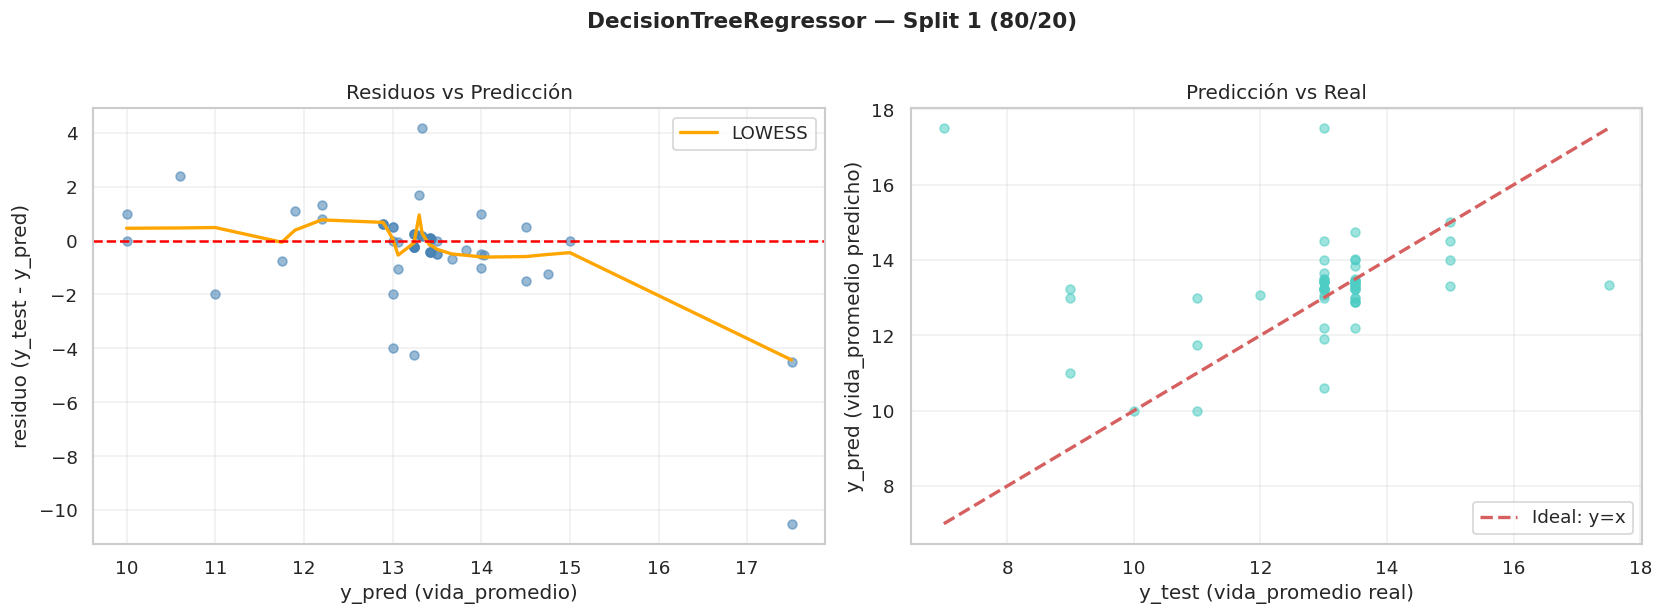

💾 Gráficas guardadas → /home/molina211/ETL-MineríaDeDatos/Corte_3/Semana13-ÁrbolDeDecisión /data-dogs/data/graficas/dt_dogs_80-20.png


In [ ]:
# ── CELDA 5: Split 1 — 80/20 ─────────────────────────────────
modelo_s1, y_test_s1, y_pred_s1 = evaluar_split(
    X, y,
    test_size=0.20,
    split_label='Split 1 (80/20)',
    resultados_globales=resultados_globales,
)


---



  Split 2 (70/30) — 70% Train / 30% Test
  n_train=198 | n_test=85
R2   = -0.3850
MSE  = 2.8393
RMSE = 1.6850 años
MAE  = 0.8803 años
Árbol: depth=9 | leaves=51


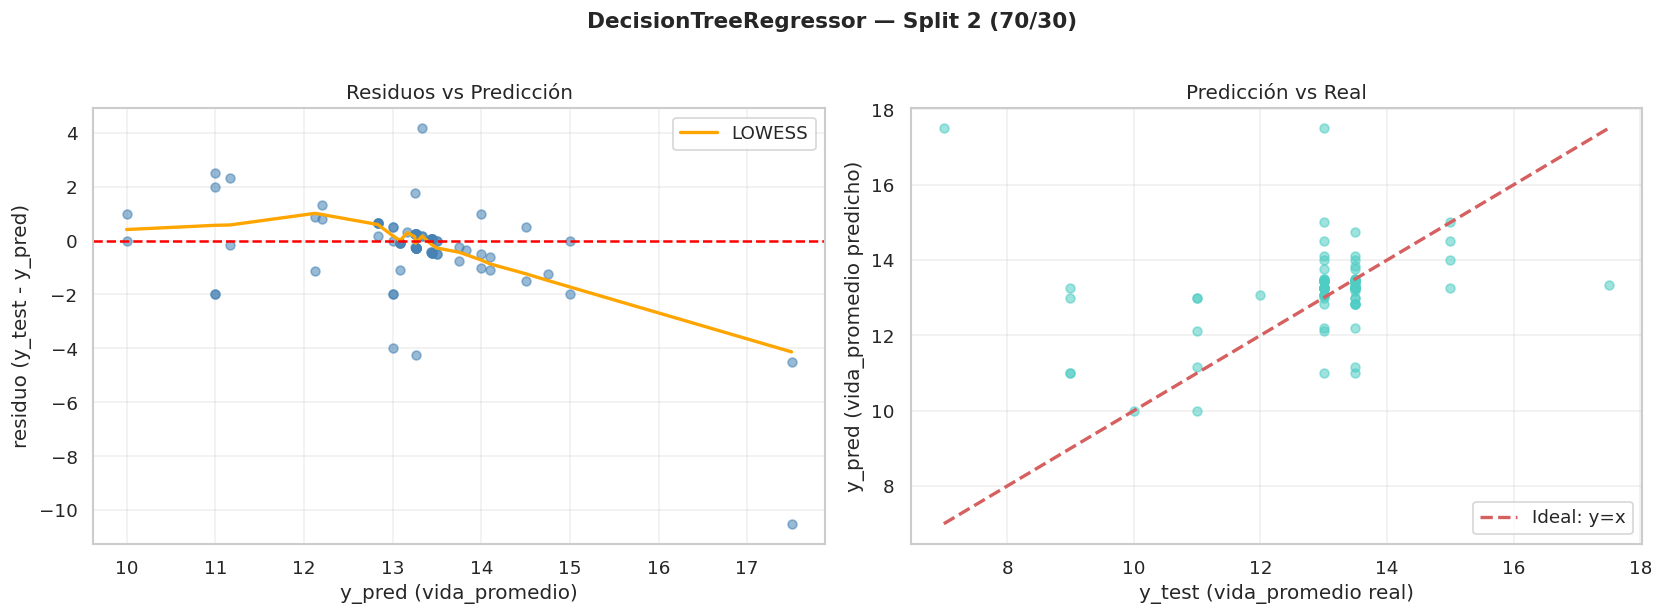

💾 Gráficas guardadas → /home/molina211/ETL-MineríaDeDatos/Corte_3/Semana13-ÁrbolDeDecisión /data-dogs/data/graficas/dt_dogs_70-30.png


In [8]:
# ── CELDA 6: Split 2 — 70/30 ─────────────────────────────────
modelo_s2, y_test_s2, y_pred_s2 = evaluar_split(
    X, y,
    test_size=0.30,
    split_label='Split 2 (70/30)',
    resultados_globales=resultados_globales,
)


---



  Split 3 (60/40) — 60% Train / 40% Test
  n_train=169 | n_test=114
R2   = -0.1039
MSE  = 2.3957
RMSE = 1.5478 años
MAE  = 0.8551 años
Árbol: depth=10 | leaves=50


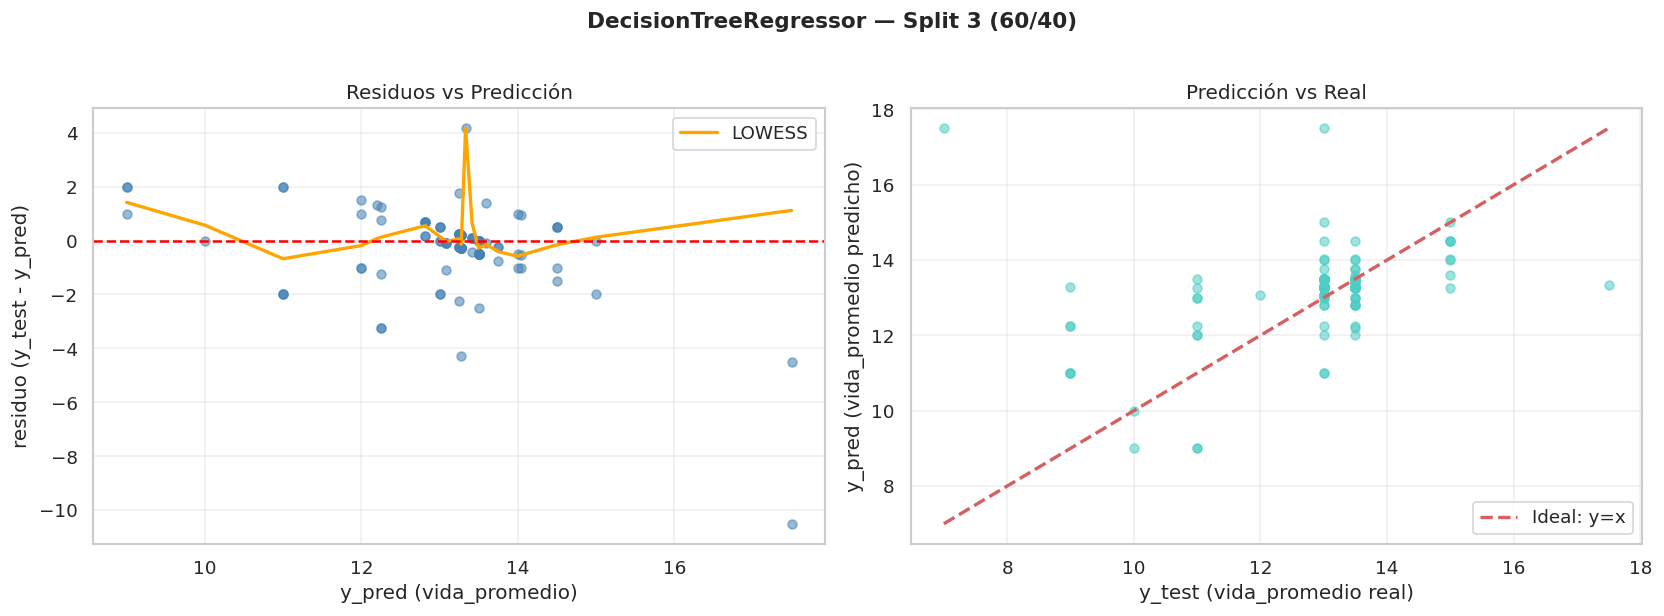

💾 Gráficas guardadas → /home/molina211/ETL-MineríaDeDatos/Corte_3/Semana13-ÁrbolDeDecisión /data-dogs/data/graficas/dt_dogs_60-40.png


In [9]:
# ── CELDA 7: Split 3 — 60/40 ─────────────────────────────────
modelo_s3, y_test_s3, y_pred_s3 = evaluar_split(
    X, y,
    test_size=0.40,
    split_label='Split 3 (60/40)',
    resultados_globales=resultados_globales,
)


---


In [10]:
# ── CELDA 8: Tabla comparativa de métricas ───────────────────
df_resumen = pd.DataFrame(resultados_globales)

print('=' * 65)
print('        TABLA COMPARATIVA — TRES SPLITS (DOGS)')
print('=' * 65)
print(df_resumen.to_string(index=False))
print('=' * 65)

df_resumen


        TABLA COMPARATIVA — TRES SPLITS (DOGS)
Split  n_train  n_test      R2    MSE   RMSE    MAE  Profundidad  Hojas
80/20      226      57 -0.4613 3.7788 1.9439 1.0090           11     56
70/30      198      85 -0.3850 2.8393 1.6850 0.8803            9     51
60/40      169     114 -0.1039 2.3957 1.5478 0.8551           10     50


,Split,n_train,n_test,R2,MSE,RMSE,MAE,Profundidad,Hojas
0,80/20,226,57,-0.4613,3.7788,1.9439,1.0090,11,56
1,70/30,198,85,-0.3850,2.8393,1.6850,0.8803,9,51
2,60/40,169,114,-0.1039,2.3957,1.5478,0.8551,10,50


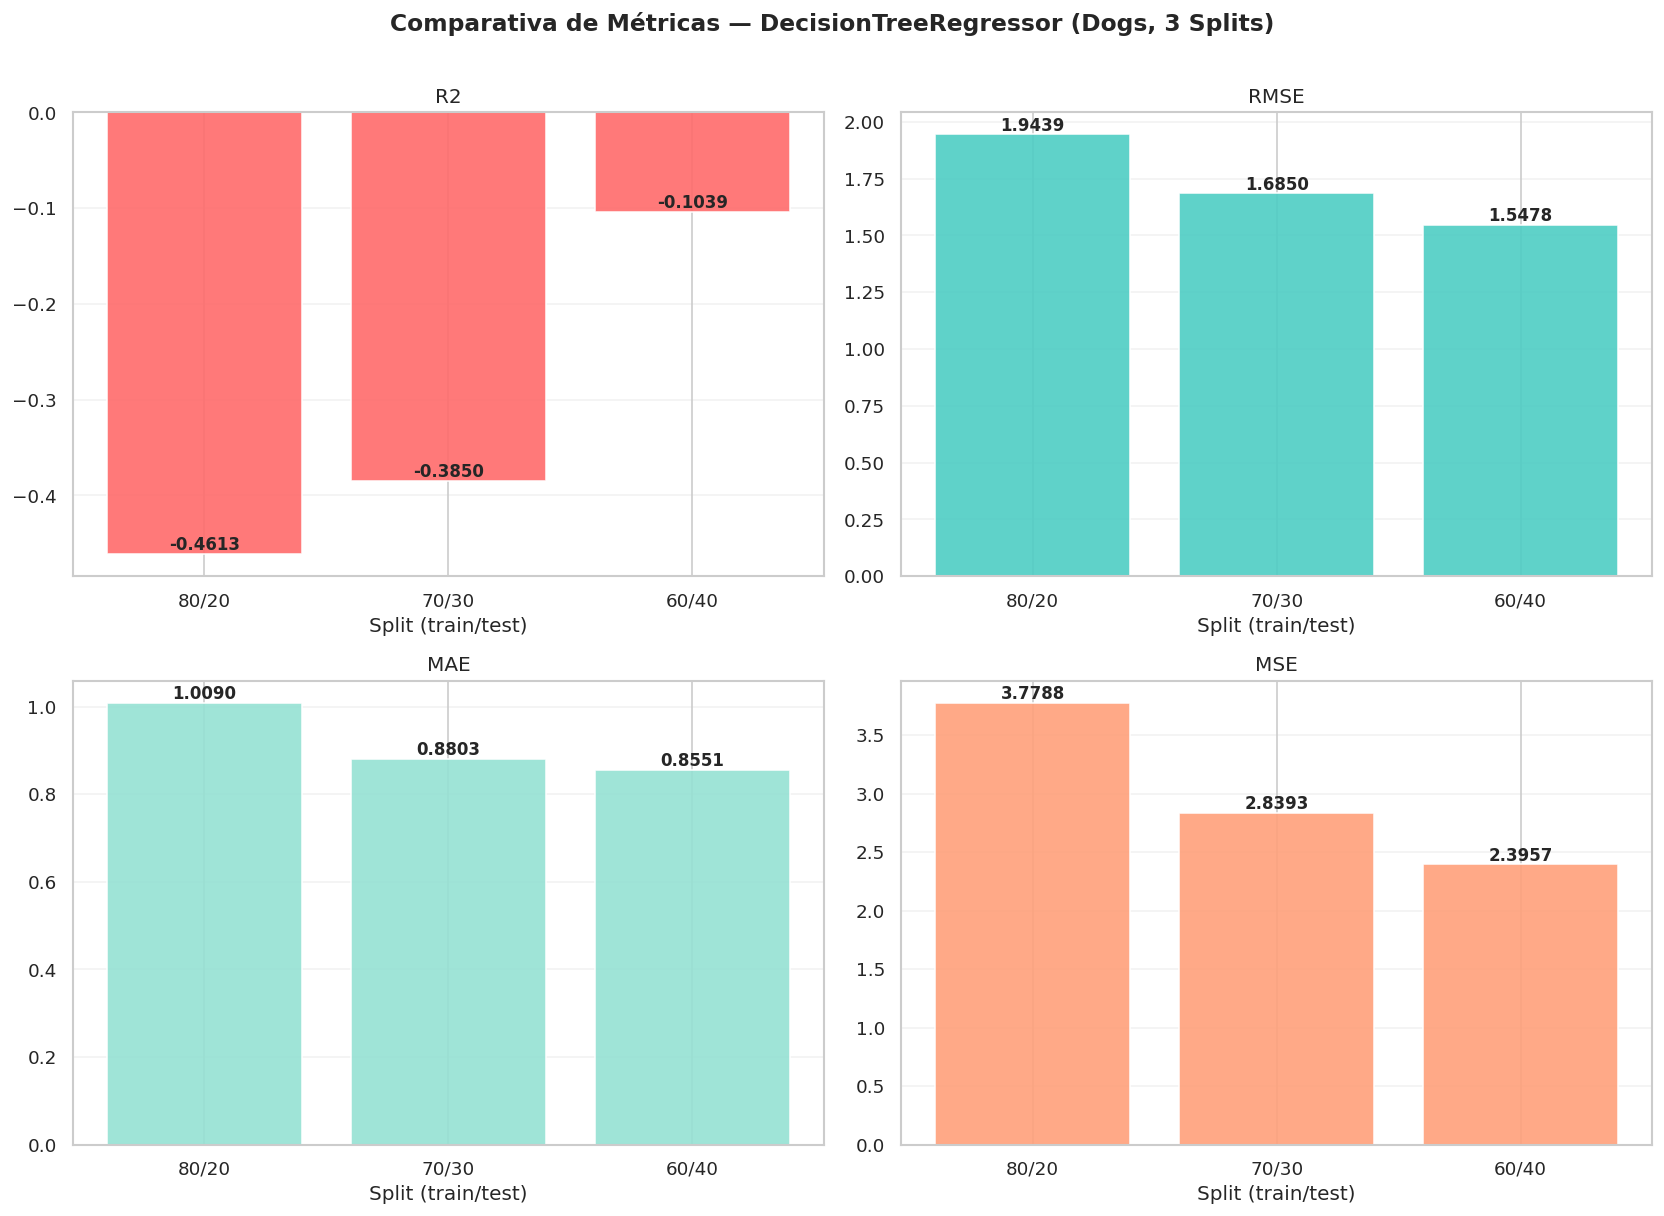

💾 Gráfico comparativo guardado → ../data/graficas/dt_dogs_comparativa_splits.png


In [11]:
# ── CELDA 9: Gráfico comparativo de métricas por split ───────
metricas = ['R2', 'RMSE', 'MAE', 'MSE']
colores  = ['#ff6b6b', '#4ecdc4', '#95e1d3', '#ffa07a']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparativa de Métricas — DecisionTreeRegressor (Dogs, 3 Splits)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (metrica, color) in zip(axes.flat, zip(metricas, colores)):
    valores = df_resumen[metrica].values
    ax.bar(df_resumen['Split'], valores, color=color, alpha=0.9)
    ax.set_title(metrica)
    ax.set_xlabel('Split (train/test)')
    ax.grid(axis='y', alpha=0.25)
    for i, v in enumerate(valores):
        ax.text(i, v, f'{v:.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/graficas/dt_dogs_comparativa_splits.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('💾 Gráfico comparativo guardado → ../data/graficas/dt_dogs_comparativa_splits.png')


In [12]:
# ── CELDA 10: Análisis interpretativo y recomendación ────────
r2_vals   = df_resumen['R2'].values
rmse_vals = df_resumen['RMSE'].values
mae_vals  = df_resumen['MAE'].values

r2_rango   = r2_vals.max()   - r2_vals.min()
rmse_rango = rmse_vals.max() - rmse_vals.min()

print('=' * 65)
print('   ANÁLISIS CONSOLIDADO — DecisionTreeRegressor (DOGS)')
print('=' * 65)

print('\n1. VARIACIÓN DEL RENDIMIENTO ENTRE SPLITS')
print('─────────────────────────────────────────')
print(f'   R2   máx={r2_vals.max():.4f}  mín={r2_vals.min():.4f}  rango={r2_rango:.4f}')
print(f'   RMSE máx={rmse_vals.max():.4f}  mín={rmse_vals.min():.4f}  rango={rmse_rango:.4f}')

if r2_rango < 0.05:
    print('\n✅ El R2 es estable en los tres splits (variación < 0.05).')
    print('   Esto sugiere que el árbol captura patrones consistentes')
    print('   y no depende críticamente del tamaño del entrenamiento.')
else:
    print('\n⚠️  El R2 varía notablemente entre splits (variación ≥ 0.05).')
    print('   Recomendación: regularizar (max_depth, min_samples_leaf).')

print('\n2. LECTURA DE LAS MÉTRICAS')
print('─────────────────────────')
print('- R2 mide proporción de varianza explicada (más alto es mejor).')
print('- RMSE y MAE están en años: indican el error típico de predicción.')
print('- RMSE suele ser mayor que MAE si existen algunos errores grandes.')

print('\n3. RECOMENDACIÓN')
print('────────────────')
print('- Usar este árbol como baseline no lineal.')
print('- Si el árbol queda muy profundo o con muchas hojas, probar regularización')
print('  o escalar a ensembles (Random Forest / Gradient Boosting).')

print('=' * 65)


   ANÁLISIS CONSOLIDADO — DecisionTreeRegressor (DOGS)

1. VARIACIÓN DEL RENDIMIENTO ENTRE SPLITS
─────────────────────────────────────────
   R2   máx=-0.1039  mín=-0.4613  rango=0.3574
   RMSE máx=1.9439  mín=1.5478  rango=0.3961

⚠️  El R2 varía notablemente entre splits (variación ≥ 0.05).
   Recomendación: regularizar (max_depth, min_samples_leaf).

2. LECTURA DE LAS MÉTRICAS
─────────────────────────
- R2 mide proporción de varianza explicada (más alto es mejor).
- RMSE y MAE están en años: indican el error típico de predicción.
- RMSE suele ser mayor que MAE si existen algunos errores grandes.

3. RECOMENDACIÓN
────────────────
- Usar este árbol como baseline no lineal.
- Si el árbol queda muy profundo o con muchas hojas, probar regularización
  o escalar a ensembles (Random Forest / Gradient Boosting).


---


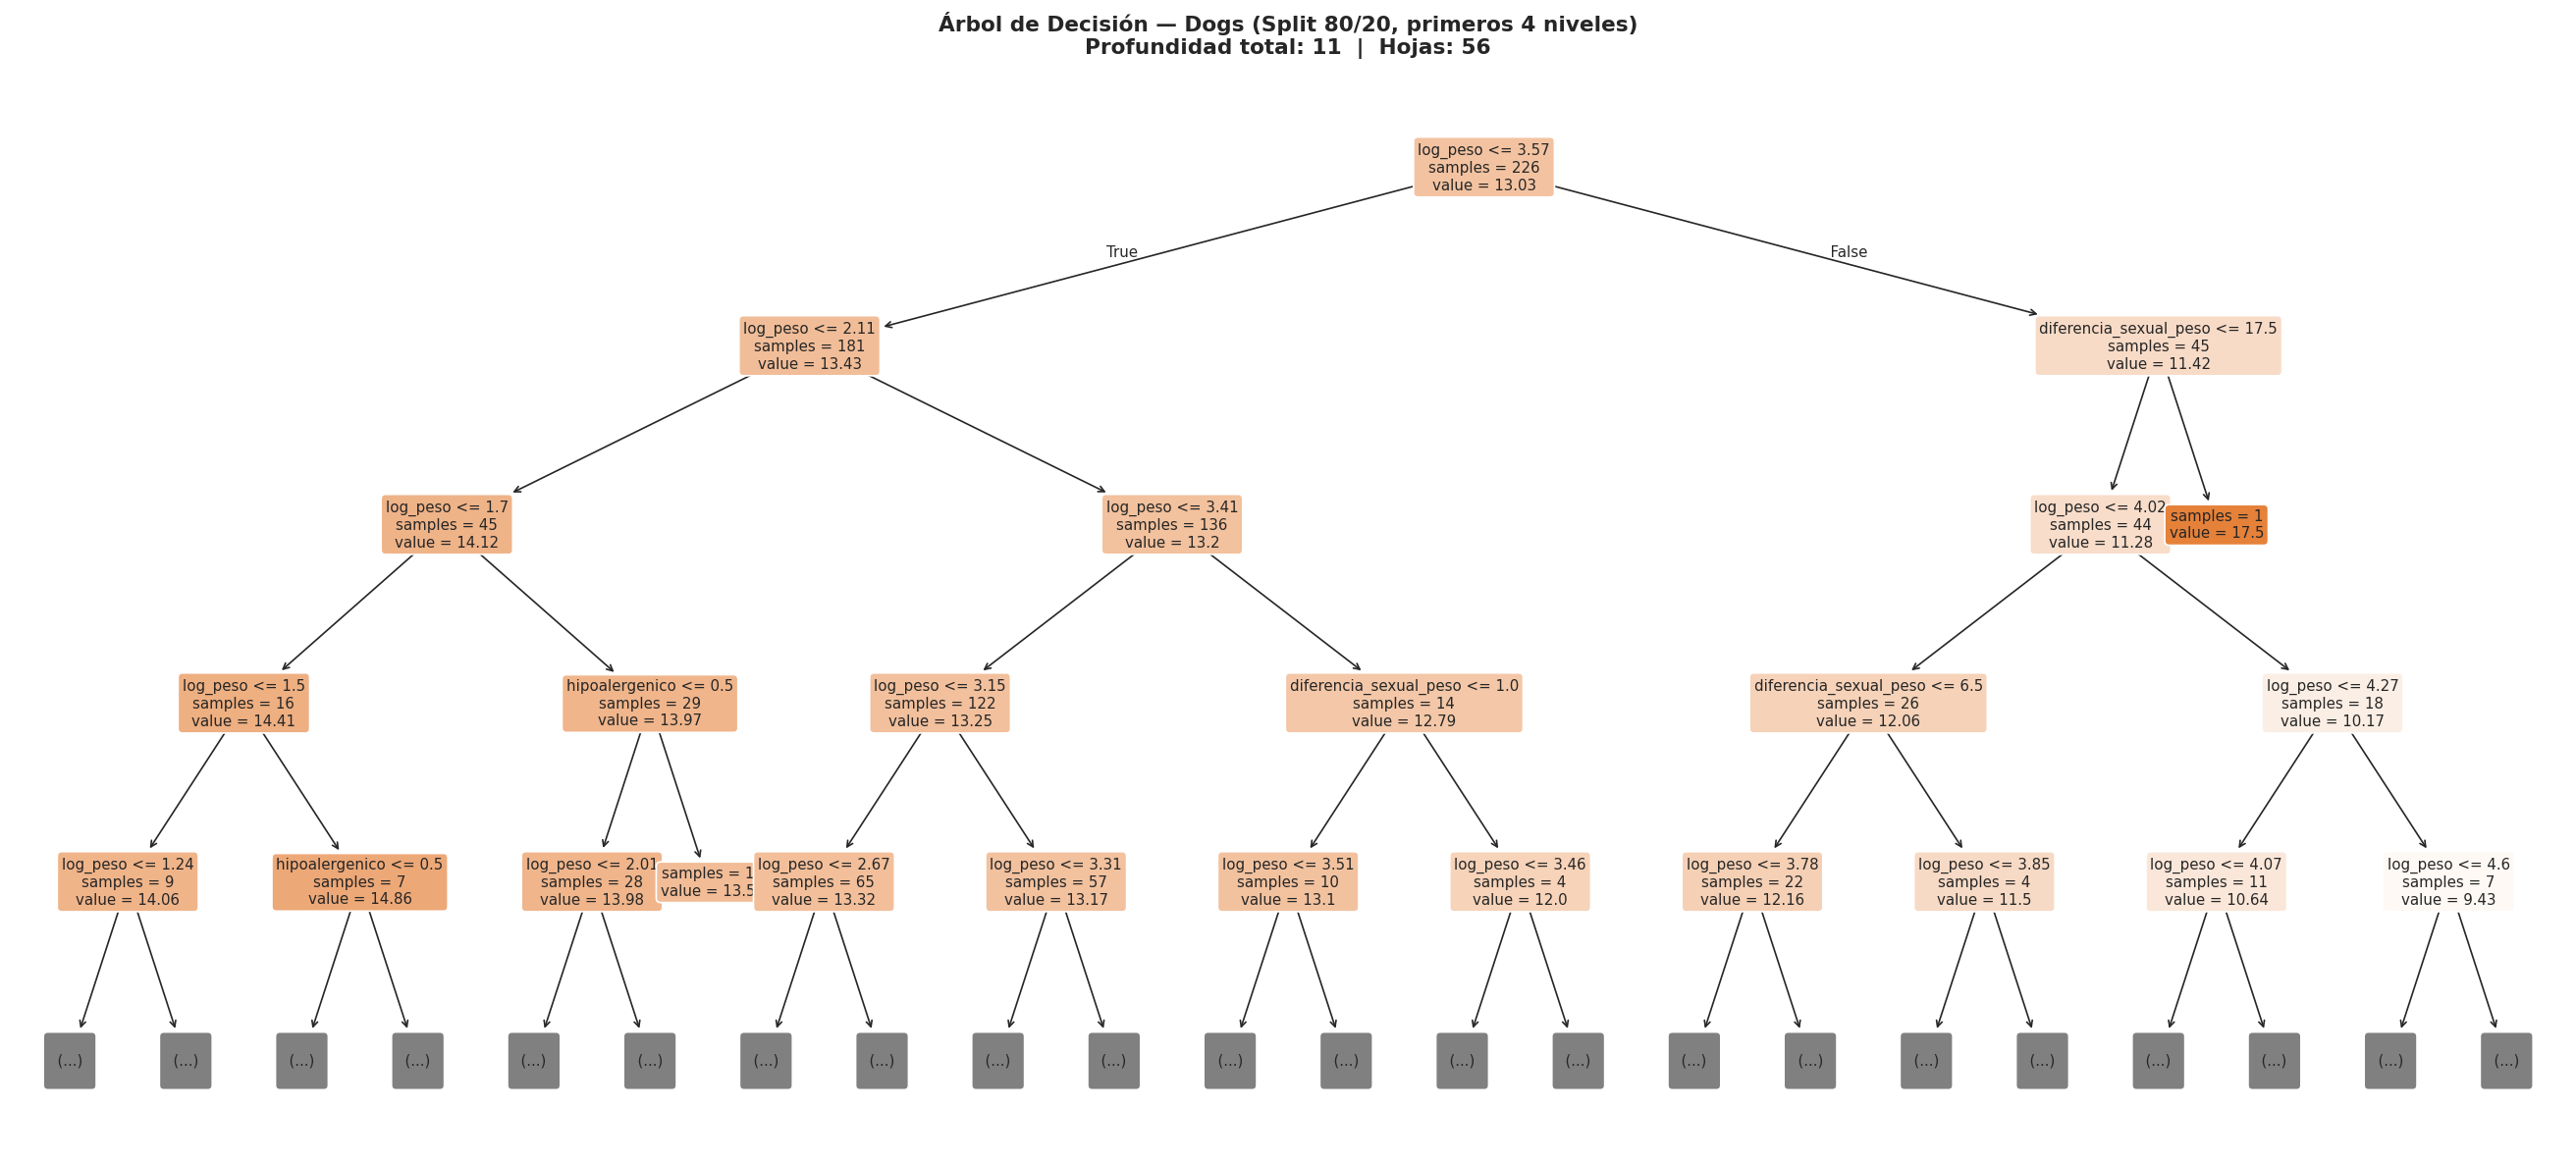

💾 Árbol real guardado → /home/molina211/ETL-MineríaDeDatos/Corte_3/Semana13-ÁrbolDeDecisión /data-dogs/data/graficas/dt_dogs_arbol_real_4niveles.png

📐 Información del árbol completo (modelo_s1):
   Profundidad máxima : 11
   Número de hojas    : 56
   Nodos totales      : 111


In [13]:
# ── CELDA 11: Visualización del árbol real (primeros 4 niveles) ──
from sklearn.tree import plot_tree, export_text
import os as _os

_GRAFICAS = _os.path.abspath('../data/graficas')
_os.makedirs(_GRAFICAS, exist_ok=True)

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    modelo_s1,
    max_depth=4,
    feature_names=features,
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=9,
    ax=ax,
)
ax.set_title(
    'Árbol de Decisión — Dogs (Split 80/20, primeros 4 niveles)\n'
    + f'Profundidad total: {modelo_s1.get_depth()}  |  Hojas: {modelo_s1.get_n_leaves()}',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
fname_real = _os.path.join(_GRAFICAS, 'dt_dogs_arbol_real_4niveles.png')
plt.savefig(fname_real, dpi=150, bbox_inches='tight')
plt.show()

print(f'💾 Árbol real guardado → {fname_real}')
print('\n📐 Información del árbol completo (modelo_s1):')
print(f'   Profundidad máxima : {modelo_s1.get_depth()}')
print(f'   Número de hojas    : {modelo_s1.get_n_leaves()}')
print(f'   Nodos totales      : {modelo_s1.tree_.node_count}')


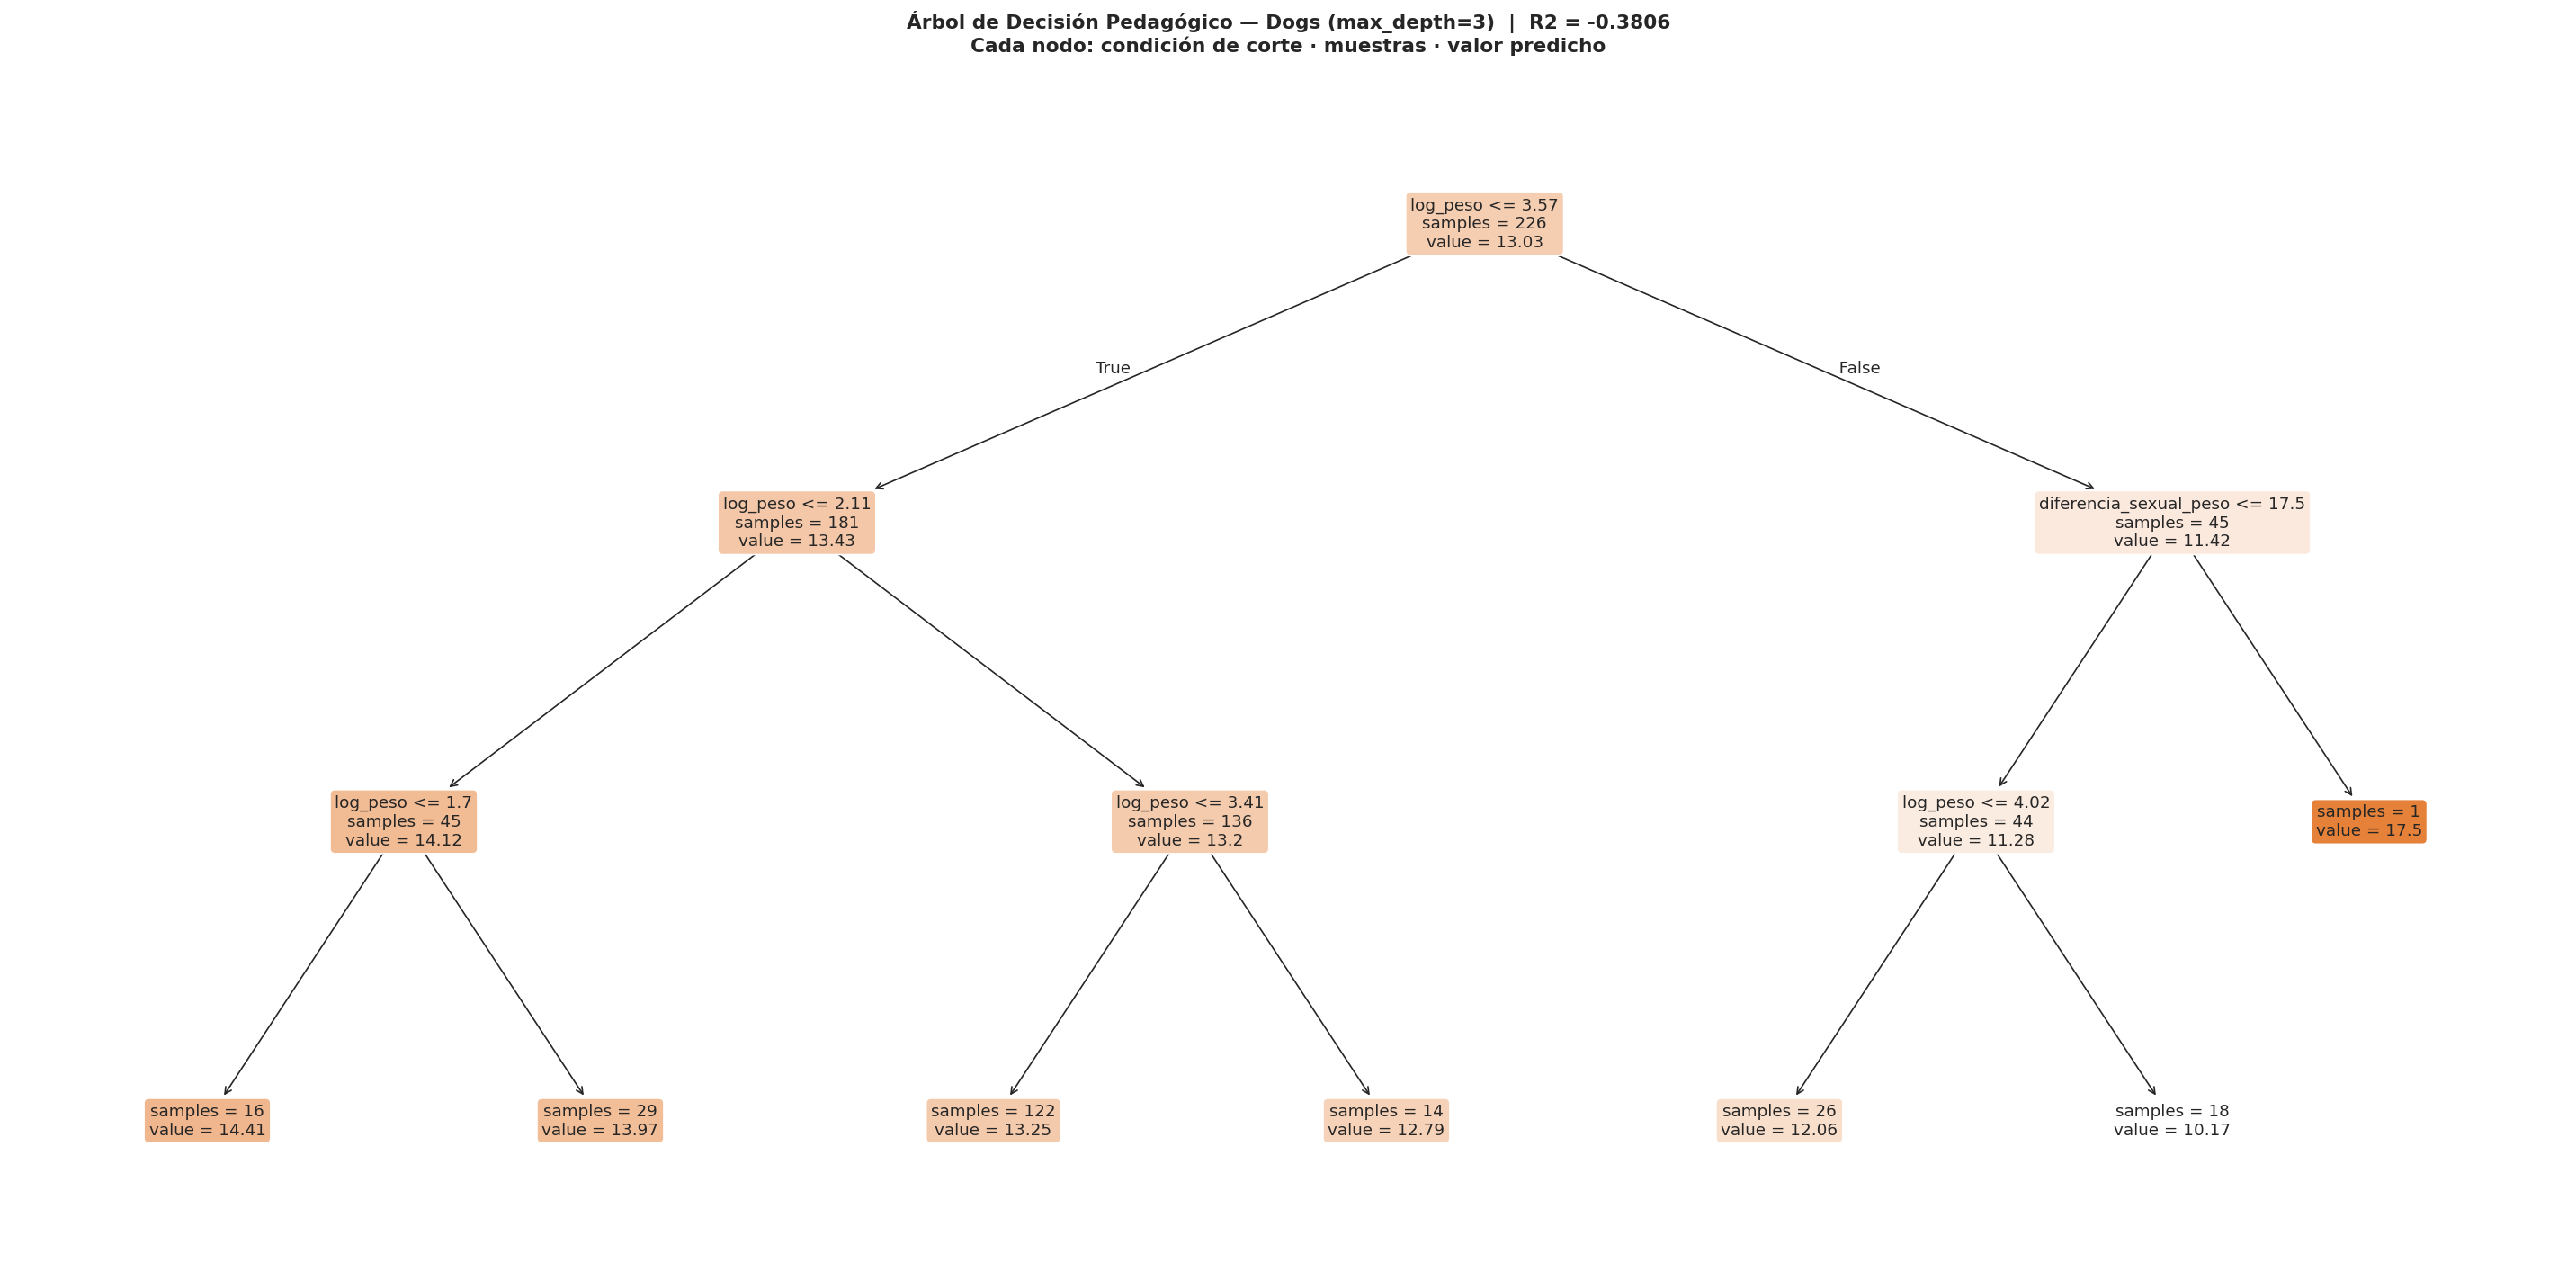

💾 Árbol pedagógico guardado → /home/molina211/ETL-MineríaDeDatos/Corte_3/Semana13-ÁrbolDeDecisión /data-dogs/data/graficas/dt_dogs_arbol_pedagogico_depth3.png
R2 del árbol pedagógico (test 20%): -0.3806


In [ ]:
# ── CELDA 12: Árbol pedagógico simplificado (max_depth=3) ─────
from sklearn.model_selection import train_test_split as _tts
from sklearn.metrics import r2_score as _r2

X_train_viz, X_test_viz, y_train_viz, y_test_viz = _tts(
    X, y, test_size=0.20, random_state=42
)

modelo_viz = DecisionTreeRegressor(max_depth=3, random_state=42)
modelo_viz.fit(X_train_viz, y_train_viz)

r2_viz = _r2(y_test_viz, modelo_viz.predict(X_test_viz))

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    modelo_viz,
    max_depth=3,
    feature_names=[str(f) for f in features],
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=11,
    ax=ax,
)
ax.set_title(
    'Árbol de Decisión Pedagógico — Dogs (max_depth=3)  |  '
    + f'R2 = {r2_viz:.4f}\n'
    + 'Cada nodo: condición de corte · muestras · valor predicho',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
fname_ped = _os.path.join(_GRAFICAS, 'dt_dogs_arbol_pedagogico_depth3.png')
plt.savefig(fname_ped, dpi=180, bbox_inches='tight')
plt.show()

print(f'💾 Árbol pedagógico guardado → {fname_ped}')
print(f'R2 del árbol pedagógico (test 20%): {r2_viz:.4f}')


In [15]:
# ── CELDA 13: Reglas de decisión en texto ─────────────────────
print('=' * 62)
print('  REGLAS DE DECISIÓN — Árbol Pedagógico (max_depth=3)')
print('=' * 62)

reglas = export_text(modelo_viz, feature_names=features)
print(reglas)

print('=' * 62)
print('📖 CÓMO LEER EL ÁRBOL:')
print('  |--- feature <= X.XX  → rama izquierda (condición VERDADERA)')
print('  |--- feature >  X.XX  → rama derecha  (condición FALSA)')
print('  |--- value: [Y.YY]    → vida_promedio predicha (años)')
print('  El árbol recorre los nodos de arriba hacia abajo hasta')
print("  llegar a una hoja y retorna su 'value' como predicción.")
print('=' * 62)


  REGLAS DE DECISIÓN — Árbol Pedagógico (max_depth=3)
|--- log_peso <= 3.57
|   |--- log_peso <= 2.11
|   |   |--- log_peso <= 1.70
|   |   |   |--- value: [14.41]
|   |   |--- log_peso >  1.70
|   |   |   |--- value: [13.97]
|   |--- log_peso >  2.11
|   |   |--- log_peso <= 3.41
|   |   |   |--- value: [13.25]
|   |   |--- log_peso >  3.41
|   |   |   |--- value: [12.79]
|--- log_peso >  3.57
|   |--- diferencia_sexual_peso <= 17.50
|   |   |--- log_peso <= 4.02
|   |   |   |--- value: [12.06]
|   |   |--- log_peso >  4.02
|   |   |   |--- value: [10.17]
|   |--- diferencia_sexual_peso >  17.50
|   |   |--- value: [17.50]

📖 CÓMO LEER EL ÁRBOL:
  |--- feature <= X.XX  → rama izquierda (condición VERDADERA)
  |--- feature >  X.XX  → rama derecha  (condición FALSA)
  |--- value: [Y.YY]    → vida_promedio predicha (años)
  El árbol recorre los nodos de arriba hacia abajo hasta
  llegar a una hoja y retorna su 'value' como predicción.


---
